In [2]:
import math

from GroundTruth import loadSheet
import mysql.connector
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

mydb = mysql.connector.connect(
  host="localhost",
  user="root",
  password="MyN3wP4ssw0rd",
  database="democratizeesg"
)

mycursor = mydb.cursor()

sql_query = "SELECT * FROM democratizeesg.big_dataset_consolidated;"
mycursor.execute(sql_query)
results = mycursor.fetchall()
column_names = [desc[0] for desc in mycursor.description]
df = pd.DataFrame(results, columns=column_names)

industry_specific_indicators_sheet = loadSheet("1QoOHmD0nxb52BIVpKyniVdYej1W5o1-sNot7DpaBl2w", "IndustrySpecificIndicators!A1:L")
industry_agnostic_indicators_sheet = loadSheet("1QoOHmD0nxb52BIVpKyniVdYej1W5o1-sNot7DpaBl2w", "IndustryAgnostricIndicators!A1:L")

In [18]:
sql_query = "SELECT industry, year, sum(value) AS emissions_scope1 FROM democratizeesg.big_dataset_consolidated_unit_converted3 WHERE  indicator_id = %s GROUP BY industry, year"
val = ["ghg_scope1"]
mycursor.execute(sql_query, val)
results = mycursor.fetchall()
column_names = [desc[0] for desc in mycursor.description]
df_ghg_scope1 = pd.DataFrame(results, columns=column_names)

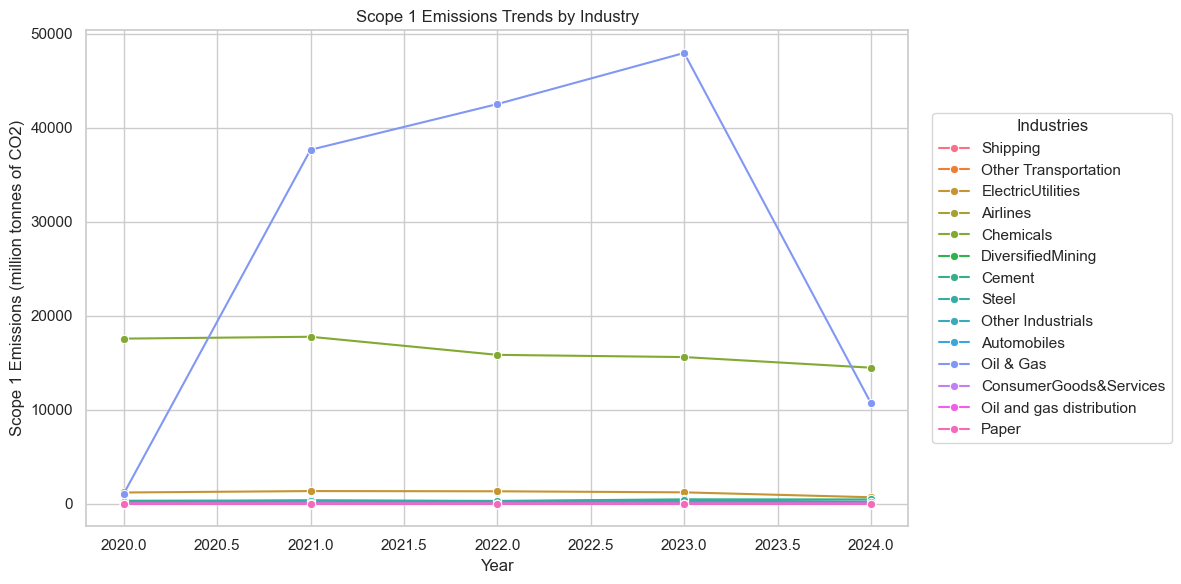

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

df_ghg_scope1['year'] = df_ghg_scope1['year'].astype(int)
sns.set_theme(style="whitegrid", palette="pastel")# Set the figure size to make it nice and wide
plt.figure(figsize=(12, 6))

# df_agg is the aggregated DataFrame from the prerequisite step
ax = sns.lineplot(data=df_ghg_scope1,
             x='year',
             y='emissions_scope1',
             hue='industry',      # 'hue' is Seaborn's version of 'color' for grouping
             marker='o')          # Adds a circle marker for each data point
# Add a title and labels
plt.title('Scope 1 Emissions Trends by Industry')
plt.xlabel('Year')
plt.ylabel('Scope 1 Emissions (million tonnes of CO2)')
plt.legend(title='Industries')
plt.grid(True) # Add a grid for readability

sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), title='Industries')
plt.tight_layout()
plt.show()

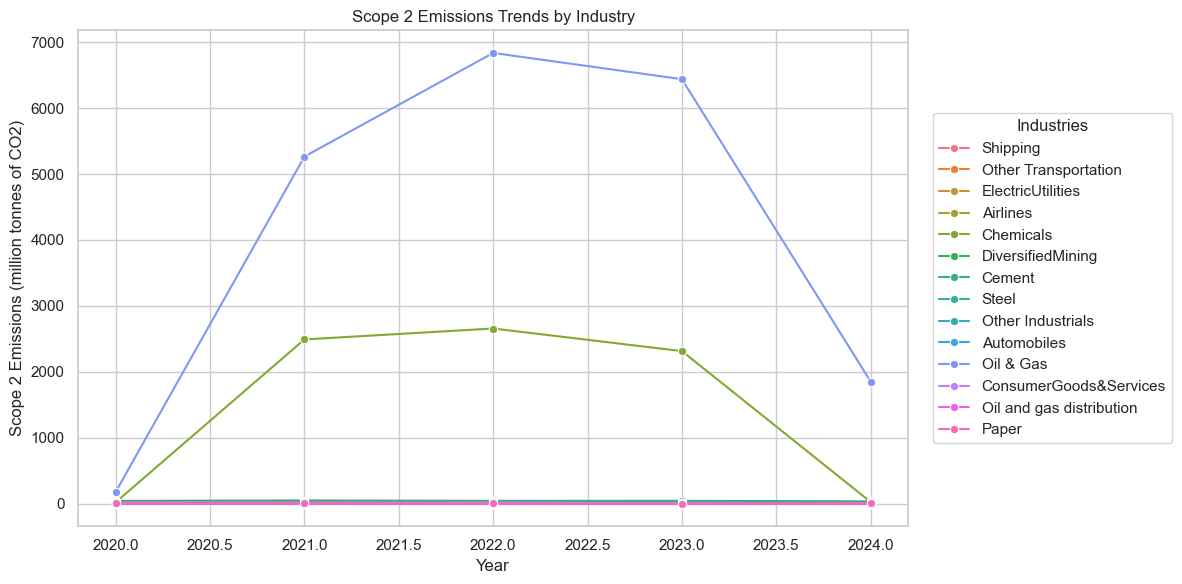

In [20]:
sql_query = ("SELECT industry, year, sum(value) AS emissions_scope2 FROM democratizeesg.big_dataset_consolidated_unit_converted3 "
             "WHERE  indicator_id = %s GROUP BY industry, year")
val = ["ghg_scope2_market"]
mycursor.execute(sql_query, val)
results = mycursor.fetchall()
column_names = [desc[0] for desc in mycursor.description]
df_ghg_scope2 = pd.DataFrame(results, columns=column_names)

df_ghg_scope2['year'] = df_ghg_scope2['year'].astype(int)
sns.set_theme(style="whitegrid", palette="pastel")# Set the figure size to make it nice and wide
plt.figure(figsize=(12, 6))

# df_agg is the aggregated DataFrame from the prerequisite step
ax = sns.lineplot(data=df_ghg_scope2,
             x='year',
             y='emissions_scope2',
             hue='industry',      # 'hue' is Seaborn's version of 'color' for grouping
             marker='o')          # Adds a circle marker for each data point
# Add a title and labels
plt.title('Scope 2 Emissions Trends by Industry')
plt.xlabel('Year')
plt.ylabel('Scope 2 Emissions (million tonnes of CO2)')
plt.legend(title='Industries')
plt.grid(True) # Add a grid for readability

sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), title='Industries')
plt.tight_layout()
plt.show()

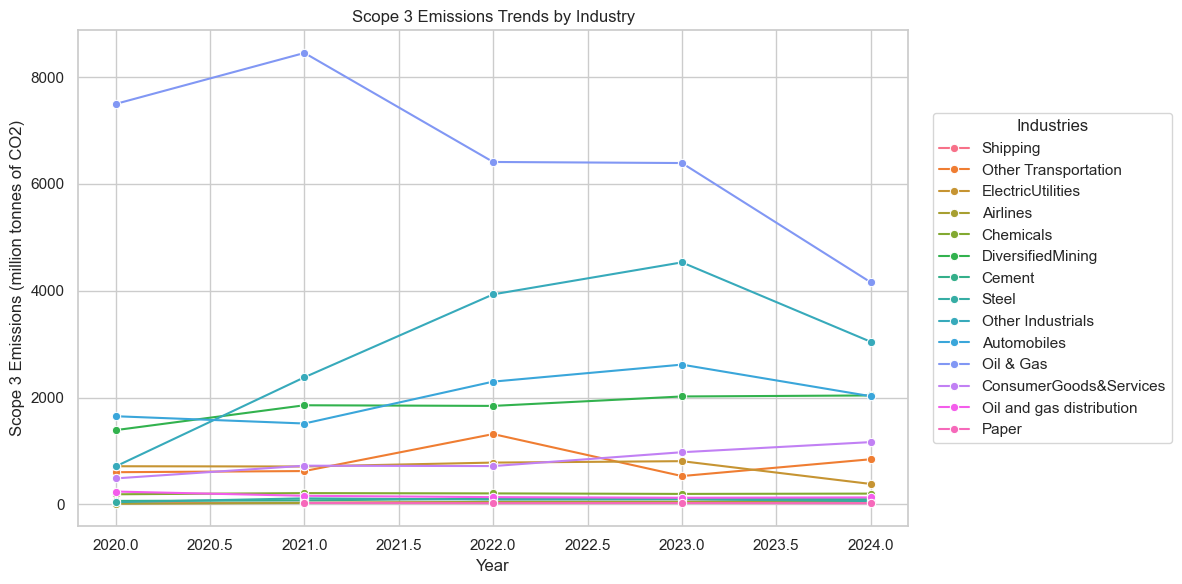

In [23]:
#Revenue
sql_query = "SELECT industry, year, sum(value) AS emissions_scope2 FROM democratizeesg.big_dataset_consolidated_unit_converted3 WHERE  indicator_id = %s GROUP BY industry, year"
val = ["ghg_scope3"]
mycursor.execute(sql_query, val)
results = mycursor.fetchall()
column_names = [desc[0] for desc in mycursor.description]
df_ghg_scope2 = pd.DataFrame(results, columns=column_names)

df_ghg_scope2['year'] = df_ghg_scope2['year'].astype(int)
sns.set_theme(style="whitegrid", palette="pastel")# Set the figure size to make it nice and wide
plt.figure(figsize=(12, 6))

# df_agg is the aggregated DataFrame from the prerequisite step
ax = sns.lineplot(data=df_ghg_scope2,
             x='year',
             y='emissions_scope2',
             hue='industry',      # 'hue' is Seaborn's version of 'color' for grouping
             marker='o')          # Adds a circle marker for each data point
# Add a title and labels
plt.title('Scope 3 Emissions Trends by Industry')
plt.xlabel('Year')
plt.ylabel('Scope 3 Emissions (million tonnes of CO2)')
plt.legend(title='Industries')
plt.grid(True) # Add a grid for readability

sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), title='Industries')
plt.tight_layout()
plt.show()

In [51]:
sql_query = ("SELECT t1.industry, t1.company_name, t1.year, t1.ghg_scope1, t1.emissions_unit, t2.revenue, t2.revenue_unit "
             "FROM	"
             "(SELECT industry, company_name, year, value AS 'ghg_scope1', unit AS 'emissions_unit' "
             "FROM democratizeesg.big_dataset_consolidated_unit_converted3    "
             "WHERE indicator_id = %s    AND not_disclosed = 0    AND unit = %s) t1 "
             "INNER JOIN "
             "(SELECT industry, company_name, year, value AS 'revenue', unit AS 'revenue_unit'    "
             "FROM democratizeesg.big_dataset_consolidated_unit_converted3     "
             "WHERE indicator_id = %s    AND not_disclosed = 0    AND unit = %s) t2 "
             "ON t1.industry = t2.industry AND t1.company_name = t2.company_name AND t1.year = t2.year")
val = ['ghg_scope1', "million tonnes of CO2", 'revenue', "billion euros"]
mycursor.execute(sql_query, val)
results = mycursor.fetchall()
column_names = [desc[0] for desc in mycursor.description]
df_intensity = pd.DataFrame(results, columns=column_names)
df_intensity['ghg_scope1'] = pd.to_numeric(df_intensity['ghg_scope1'])
df_intensity['revenue'] = pd.to_numeric(df_intensity['revenue'])

df_intensity['Intensity'] = df_intensity['ghg_scope1'] / df_intensity['revenue']
df_intensity.sort_values('ghg_scope1', ascending=False, inplace=True)

#df_intensity_outliers = df_intensity.query('Intensity > 17')
#df_intensity = df_intensity.query('Intensity < 17')
df_intensity.head(30)

,industry,company_name,year,ghg_scope1,emissions_unit,revenue,revenue_unit,Intensity
318,Oil & Gas,Lukoil,2023,36898.00,million tonnes of CO2,81.31,billion euros,453.794121
317,Oil & Gas,Lukoil,2021,36388.00,million tonnes of CO2,96.77,billion euros,376.025628
53,Chemicals,BASF,2021,17721.00,million tonnes of CO2,78.60,billion euros,225.458015
52,Chemicals,BASF,2020,17526.00,million tonnes of CO2,59.15,billion euros,296.297549
54,Chemicals,BASF,2022,15797.00,million tonnes of CO2,87.33,billion euros,180.888584
55,Chemicals,BASF,2023,15562.00,million tonnes of CO2,68.90,billion euros,225.863570
56,Chemicals,BASF,2024,14432.00,million tonnes of CO2,65.26,billion euros,221.146184
141,Oil & Gas,CNOOC,2024,9875.62,million tonnes of CO2,50.46,billion euros,195.711851
140,Oil & Gas,CNOOC,2023,9778.55,million tonnes of CO2,49.99,billion euros,195.610122
374,ElectricUtilities,NTPC,2024,353.29,million tonnes of CO2,17.52,billion euros,20.164954


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Oil & Gas'),
  Text(1, 0, 'Chemicals'),
  Text(2, 0, 'Cement'),
  Text(3, 0, 'ElectricUtilities'),
  Text(4, 0, 'DiversifiedMining'),
  Text(5, 0, 'Steel'),
  Text(6, 0, 'Airlines'),
  Text(7, 0, 'Shipping'),
  Text(8, 0, 'Other Industrials'),
  Text(9, 0, 'Oil and gas distribution'),
  Text(10, 0, 'Paper'),
  Text(11, 0, 'ConsumerGoods&Services'),
  Text(12, 0, 'Automobiles'),
  Text(13, 0, 'Other Transportation')])

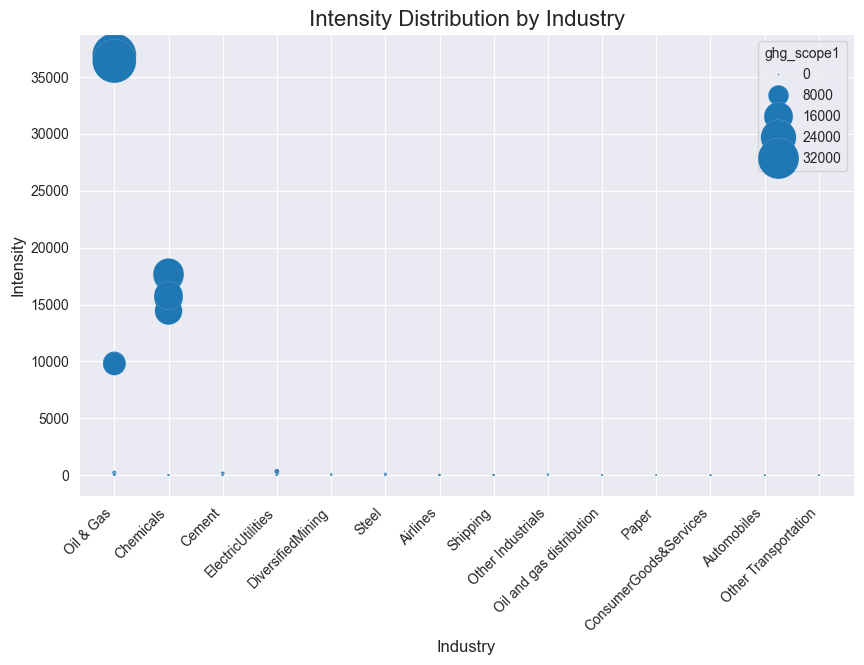

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_intensity, x='industry', y='ghg_scope1', size='ghg_scope1', sizes=(1,1000))
plt.title('Intensity Distribution by Industry', fontsize=16)
plt.xlabel('Industry', fontsize=12)
plt.ylabel('Intensity', fontsize=12)

# Rotate x-axis labels to prevent them from overlapping
# This is crucial if you have many industries or long names
plt.xticks(rotation=45, ha='right')

# Ensure all labels and titles fit within the image
#plt.tight_layout()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Cement'),
  Text(1, 0, 'ElectricUtilities'),
  Text(2, 0, 'DiversifiedMining'),
  Text(3, 0, 'Steel'),
  Text(4, 0, 'Oil & Gas'),
  Text(5, 0, 'Airlines'),
  Text(6, 0, 'Shipping'),
  Text(7, 0, 'Other Industrials'),
  Text(8, 0, 'Oil and gas distribution'),
  Text(9, 0, 'Chemicals'),
  Text(10, 0, 'Paper'),
  Text(11, 0, 'ConsumerGoods&Services'),
  Text(12, 0, 'Automobiles'),
  Text(13, 0, 'Other Transportation')])

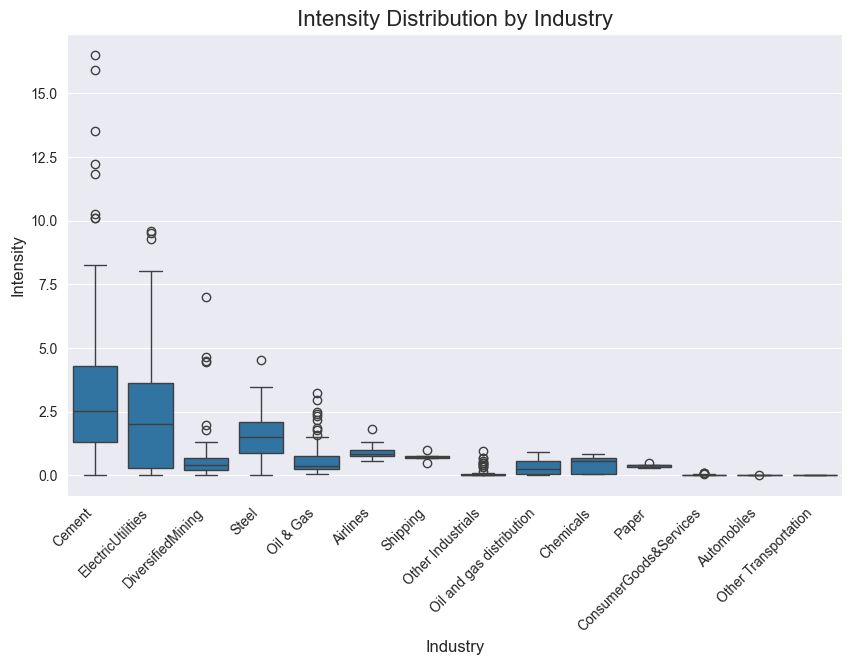

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_intensity, x='industry', y='Intensity')
plt.title('Intensity Distribution by Industry', fontsize=16)
plt.xlabel('Industry', fontsize=12)
plt.ylabel('Intensity', fontsize=12)

# Rotate x-axis labels to prevent them from overlapping
# This is crucial if you have many industries or long names
plt.xticks(rotation=45, ha='right')

# Ensure all labels and titles fit within the image
#plt.tight_layout()

In [77]:
sql_query = ("SELECT t1.industry, t1.company_name, t1.year, t1.ghg_scope1, t3.ghg_scope2, t4.ghg_scope3, t1.emissions_unit, t2.revenue, t2.revenue_unit "
             "FROM	"
             "(SELECT industry, company_name, year, value AS 'ghg_scope1', unit AS 'emissions_unit'    "
             "FROM democratizeesg.big_dataset_consolidated_unit_converted3    "
             "WHERE indicator_id = %s  ) t1 "
             "INNER JOIN "
             "(SELECT industry, company_name, year, value AS 'revenue', unit AS 'revenue_unit'    "
             "FROM democratizeesg.big_dataset_consolidated_unit_converted3    "
             "WHERE indicator_id = %s     ) t2 "
             "ON t1.industry = t2.industry AND t1.company_name = t2.company_name AND t1.year = t2.year "
             "INNER JOIN "
             "(SELECT industry, company_name, year, value AS 'ghg_scope2'    "
             "FROM democratizeesg.big_dataset_consolidated_unit_converted3    "
             "WHERE indicator_id = %s     ) t3 "
             "ON t1.industry = t3.industry AND t1.company_name = t3.company_name AND t1.year = t3.year "
             "INNER JOIN "
             "(SELECT industry, company_name, year, value AS 'ghg_scope3'    "
             "FROM democratizeesg.big_dataset_consolidated_unit_converted3    "
             "WHERE indicator_id = %s     ) t4 "
             "ON t1.industry = t4.industry AND t1.company_name = t4.company_name AND t1.year = t4.year")
val = ['ghg_scope1', 'revenue',  'ghg_scope2_market', 'ghg_scope3']
mycursor.execute(sql_query, val)
results = mycursor.fetchall()
column_names = [desc[0] for desc in mycursor.description]
df_intensity = pd.DataFrame(results, columns=column_names)
df_intensity['ghg_scope1'] = pd.to_numeric(df_intensity['ghg_scope1'])
df_intensity['ghg_scope2'] = pd.to_numeric(df_intensity['ghg_scope2'])
df_intensity['ghg_scope3'] = pd.to_numeric(df_intensity['ghg_scope3'])
df_intensity['revenue'] = pd.to_numeric(df_intensity['revenue'])
df_intensity['ghg_scope1'].fillna(0.0, inplace=True)
df_intensity['ghg_scope2'].fillna(0.0, inplace=True)
df_intensity['ghg_scope3'].fillna(0.0, inplace=True)
df_intensity['revenue'].fillna(0.0, inplace=True)
df_intensity['emissions_unit'].fillna('million tonnes of CO2', inplace=True)
df_intensity['revenue_unit'].fillna('billion euros', inplace=True)

df_intensity['total_emissions'] = round(df_intensity['ghg_scope1'] + df_intensity['ghg_scope2'] + df_intensity['ghg_scope3'], 2)
df_intensity.sort_values('total_emissions', ascending=False, inplace=True)

df_intensity_top50 = df_intensity['company_name'].unique()[:50]

df_intensity.head(20)

C:\Users\yotim\AppData\Local\Temp\ipykernel_21212\2278369683.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_intensity['ghg_scope1'].fillna(0.0, inplace=True)
C:\Users\yotim\AppData\Local\Temp\ipykernel_21212\2278369683.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

,industry,company_name,year,ghg_scope1,ghg_scope2,ghg_scope3,emissions_unit,revenue,revenue_unit,total_emissions
369,Oil & Gas,Lukoil,2022,41202.00,5685.00,0.00,min tonnes of CO₂e,0.00,billion euros,46887.00
370,Oil & Gas,Lukoil,2023,36898.00,4921.00,0.00,million tonnes of CO2,81.31,billion euros,41819.00
368,Oil & Gas,Lukoil,2021,36388.00,5103.00,0.00,million tonnes of CO2,96.77,billion euros,41491.00
65,Chemicals,BASF,2021,17721.00,2464.00,101.00,million tonnes of CO2,78.60,billion euros,20286.00
66,Chemicals,BASF,2022,15797.00,2629.00,92.00,million tonnes of CO2,87.33,billion euros,18518.00
67,Chemicals,BASF,2023,15562.00,2289.00,85.00,million tonnes of CO2,68.90,billion euros,17936.00
64,Chemicals,BASF,2020,17526.00,3.28,92.00,million tonnes of CO2,59.15,billion euros,17621.28
68,Chemicals,BASF,2024,14432.00,2.40,91.64,million tonnes of CO2,65.26,billion euros,14526.04
159,Oil & Gas,CNOOC,2024,9875.62,1728.19,0.00,million tonnes of CO2,50.46,billion euros,11603.81
158,Oil & Gas,CNOOC,2023,9778.55,1346.26,0.00,million tonnes of CO2,49.99,billion euros,11124.81


In [76]:
df_intensity_top50

array(['Lukoil', 'BASF', 'CNOOC', 'bp', 'Gazprom', 'Shell plc',
       'Mitsubishi Heavy Industries, Ltd.', 'Cummins Inc.',
       'GE Vernova (former General Electric Co.)', 'MarathonPetroleum',
       'Caterpillar Inc.', 'Rosneft Oil Company', 'Chevron', 'Walmart',
       'RioTinto', 'Toyota', 'Airbus SE', 'ValeSA',
       'Petróleo Brasileiro S.A.', 'Petróleos Mexicanos', 'Eni',
       'Glencore', 'TotalEnergies', 'Volkswagen', 'BHP', 'Stellantis',
       'PTT Public Co. Ltd.', 'Eskom', 'Phillips 66', 'The Boeing Co.',
       'Ford', 'Trane Technologies plc', 'Daikin Industries, Ltd.',
       'NTPC', 'GeneralMotors', 'Honda', 'EquinorASA', 'AB Volvo',
       'ConocoPhillips', 'OccidentalPetroleum', 'Kepco', 'Eneos',
       'Repsol, S.A.', 'TheHomeDepot', 'OMV', 'Exelon', 'Fortum',
       'AnhuiConchCement', 'AngloAmerican', 'Nissan'], dtype=object)